In [1]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Cấu hình giao diện biểu đồ đẹp mắt
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (10, 6)

print('✅ Đã load xong các thư viện cần thiết cho EDA!')

✅ Đã load xong các thư viện cần thiết cho EDA!


In [2]:
# Xác định đường dẫn file raw
PROJECT_ROOT = Path('.').resolve().parent
RAW_FILE = PROJECT_ROOT / 'data' / 'amazon_products_sales_data_uncleaned.csv'

# Đọc dữ liệu
df_raw = pd.read_csv(RAW_FILE)

print(
    f'📊 Kích thước tập dữ liệu gốc (Shape): {df_raw.shape[0]} dòng, {df_raw.shape[1]} cột\n'
)
print('--- 5 DÒNG DỮ LIỆU ĐẦU TIÊN ---')
display(df_raw.head())

📊 Kích thước tập dữ liệu gốc (Shape): 42675 dòng, 16 cột

--- 5 DÒNG DỮ LIỆU ĐẦU TIÊN ---


,title,rating,number_of_reviews,bought_in_last_month,current/discounted_price,price_on_variant,listed_price,is_best_seller,is_sponsored,is_couponed,buy_box_availability,delivery_details,sustainability_badges,image_url,product_url,collected_at
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6 out of 5 stars,375,300+ bought in past month,89.68,basic variant price: 2.4GHz,$159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,"Delivery Mon, Sep 1",Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3 out of 5 stars,"2,457",6K+ bought in past month,9.99,basic variant price: nan,$15.99,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Fri, Aug 29",NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6 out of 5 stars,"3,044",2K+ bought in past month,314.00,basic variant price: nan,$349.00,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Mon, Sep 1",NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6 out of 5 stars,"35,882",10K+ bought in past month,NaN,basic variant price: $162.24,No Discount,Best Seller,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61SUj2aKoE...,/Apple-Cancellation-Transparency-Personalized-...,2025-08-21 11:14:29
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8 out of 5 stars,"28,988",10K+ bought in past month,NaN,basic variant price: $72.74,No Discount,No Badge,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61bMNCeAUA...,/Apple-MX542LL-A-AirTag-Pack/dp/B0D54JZTHY/ref...,2025-08-21 11:14:29


--- THÔNG TIN KIỂU DỮ LIỆU ---
<class 'pandas.DataFrame'>
RangeIndex: 42675 entries, 0 to 42674
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   title                     42675 non-null  str  
 1   rating                    41651 non-null  str  
 2   number_of_reviews         41651 non-null  str  
 3   bought_in_last_month      39458 non-null  str  
 4   current/discounted_price  30926 non-null  str  
 5   price_on_variant          42675 non-null  str  
 6   listed_price              42675 non-null  str  
 7   is_best_seller            42675 non-null  str  
 8   is_sponsored              42675 non-null  str  
 9   is_couponed               42675 non-null  str  
 10  buy_box_availability      28022 non-null  str  
 11  delivery_details          30955 non-null  str  
 12  sustainability_badges     3408 non-null   str  
 13  image_url                 42675 non-null  str  
 14  product_url       

,Số lượng Missing,Tỷ lệ (%)
sustainability_badges,39267,92.014060
buy_box_availability,14653,34.336262
current/discounted_price,11749,27.531342
delivery_details,11720,27.463386
bought_in_last_month,3217,7.538371
product_url,2069,4.848272
number_of_reviews,1024,2.399531
rating,1024,2.399531


C:\Users\Thai Vi\AppData\Local\Temp\ipykernel_19836\213188899.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


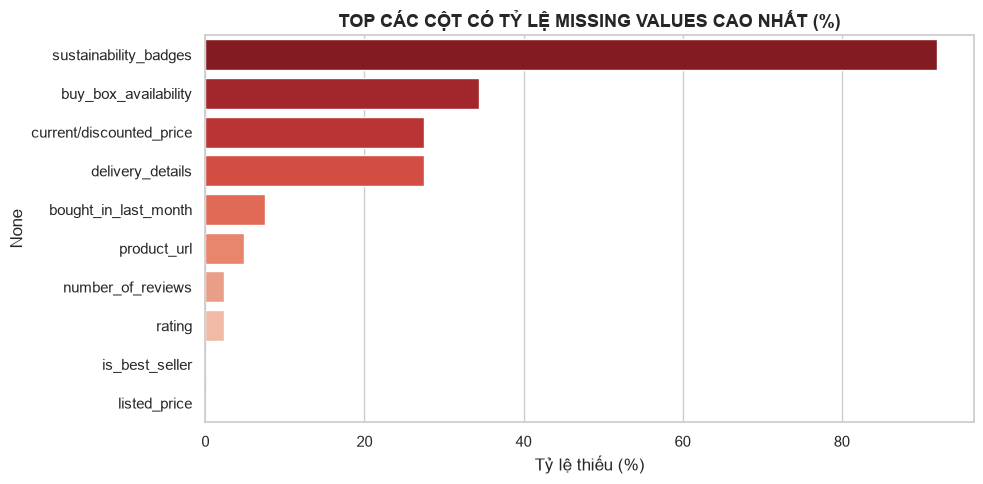

In [3]:
# 1. Thông tin tổng quan về Dtypes
print('--- THÔNG TIN KIỂU DỮ LIỆU ---')
df_raw.info()

# 2. Thống kê số lượng và tỷ lệ Missing Values
print('\n--- THỐNG KÊ GIÁ TRỊ THIẾU (MISSING VALUES) ---')
null_summary = pd.DataFrame({
    'Số lượng Missing': df_raw.isnull().sum(),
    'Tỷ lệ (%)': (df_raw.isnull().sum() / len(df_raw)) * 100,
}).sort_values(by='Số lượng Missing', ascending=False)

display(null_summary[null_summary['Số lượng Missing'] > 0])

# Trực quan hóa Missing Values
plt.figure(figsize=(10, 5))
sns.barplot(
    x=null_summary['Tỷ lệ (%)'].head(10),
    y=null_summary.head(10).index,
    palette='Reds_r',
)
plt.title(
    'TOP CÁC CỘT CÓ TỶ LỆ MISSING VALUES CAO NHẤT (%)',
    fontsize=13,
    fontweight='bold',
)
plt.xlabel('Tỷ lệ thiếu (%)')
plt.tight_layout()
plt.show()

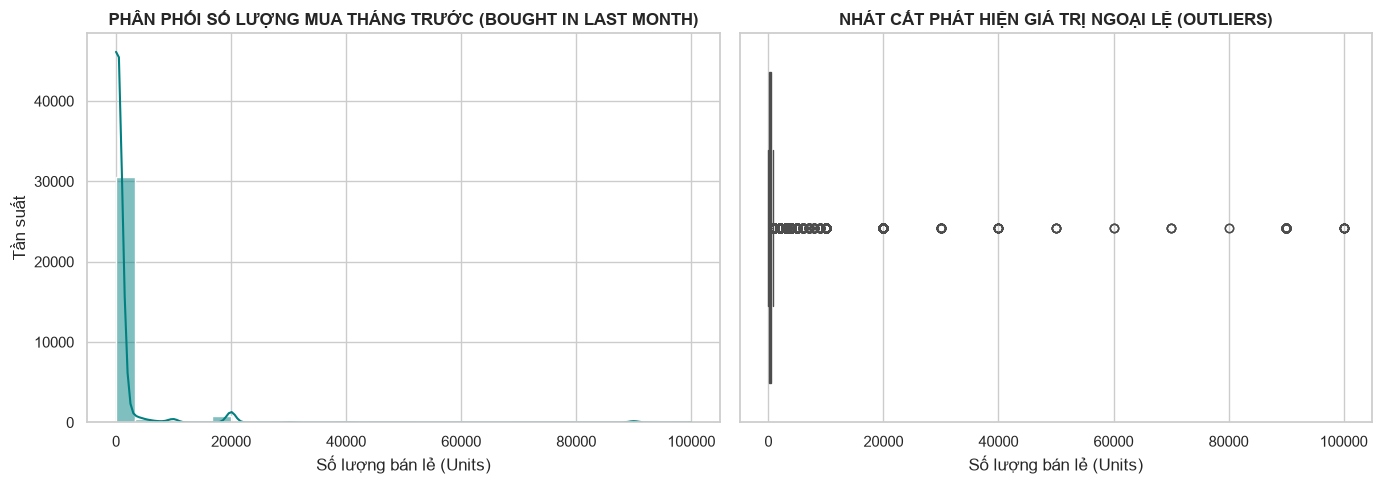

📈 Trung vị (Median) số lượng bán: 200.0 sản phẩm/tháng
📈 Giá trị lớn nhất (Max Outlier): 100000.0 sản phẩm/tháng


In [4]:
# Xử lý nhanh tạm thời cột bought_in_last_month để quan sát phân phối (EDA)
temp_bought = (
    df_raw['bought_in_last_month']
    .astype(str)
    .str.replace('+ bought in past month', '', regex=False)
    .str.replace('K', '000', regex=False)
)
temp_bought = pd.to_numeric(
    temp_bought.str.extract(r'(\d+)', expand=False), errors='coerce'
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ 1: Phân phối (Histogram/KDE)
sns.histplot(temp_bought.dropna(), kde=True, ax=axes[0], color='teal', bins=30)
axes[0].set_title(
    'PHÂN PHỐI SỐ LƯỢNG MUA THÁNG TRƯỚC (BOUGHT IN LAST MONTH)',
    fontweight='bold',
)
axes[0].set_xlabel('Số lượng bán lẻ (Units)')
axes[0].set_ylabel('Tần suất')

# Biểu đồ 2: Phát hiện Outliers bằng Boxplot
sns.boxplot(x=temp_bought, ax=axes[1], color='orange')
axes[1].set_title(
    'NHÁT CẮT PHÁT HIỆN GIÁ TRỊ NGOẠI LỆ (OUTLIERS)', fontweight='bold'
)
axes[1].set_xlabel('Số lượng bán lẻ (Units)')

plt.tight_layout()
plt.show()

print(
    f'📈 Trung vị (Median) số lượng bán: {temp_bought.median()} sản phẩm/tháng'
)
print(f'📈 Giá trị lớn nhất (Max Outlier): {temp_bought.max()} sản phẩm/tháng')

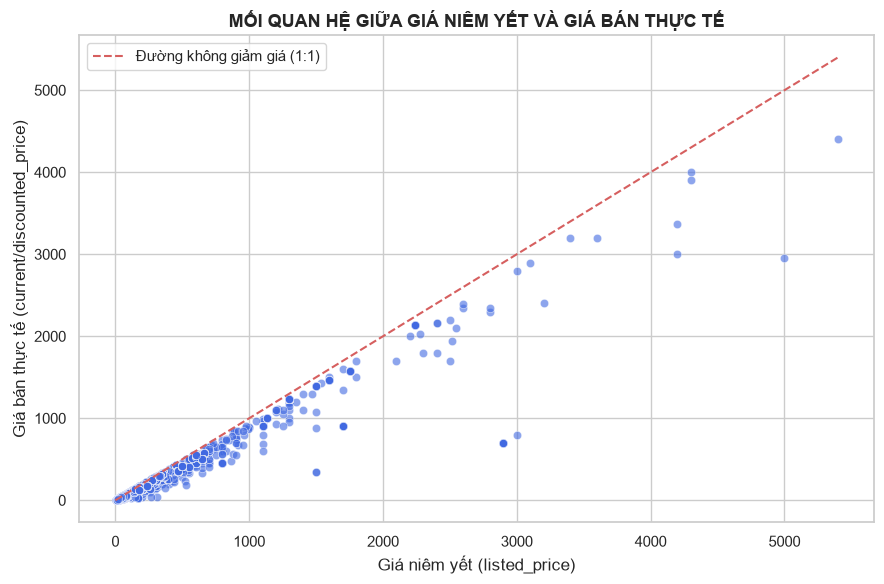

In [9]:
# Chuyển đổi sơ bộ giá tiền về dạng Float để EDA
df_eda = df_raw.copy()

# 1. Trích xuất giá trị số từ chuỗi tiền tệ (bỏ dấu phẩy, ký hiệu tiền)
col_actual = 'current/discounted_price'
col_listed = 'listed_price'

for col in [col_actual, col_listed]:
  if col in df_eda.columns:
    cleaned_s = (
        df_eda[col]
        .astype(str)
        .str.replace(',', '', regex=False)
        .str.extract(r'([\d\.]+)', expand=False)
    )
    df_eda[col] = pd.to_numeric(cleaned_s, errors='coerce')

# 2. Lọc bỏ các dòng bị NaN ở 2 cột này để vẽ biểu đồ
plot_data = df_eda.dropna(subset=[col_actual, col_listed])

# 3. Tính max an toàn cho đường tham chiếu 1:1
max_val = max(plot_data[col_actual].max(), plot_data[col_listed].max())

# 4. Vẽ Scatter plot
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=plot_data,
    x=col_listed,
    y=col_actual,
    alpha=0.6,
    color='royalblue',
)

# Đường 1:1 (Giá bán = Giá niêm yết, tức không giảm giá)
plt.plot(
    [0, max_val], [0, max_val], 'r--', label='Đường không giảm giá (1:1)'
)

plt.title(
    'MỐI QUAN HỆ GIỮA GIÁ NIÊM YẾT VÀ GIÁ BÁN THỰC TẾ',
    fontsize=13,
    fontweight='bold',
)
plt.xlabel('Giá niêm yết (listed_price)')
plt.ylabel('Giá bán thực tế (current/discounted_price)')
plt.legend()
plt.tight_layout()
plt.show()

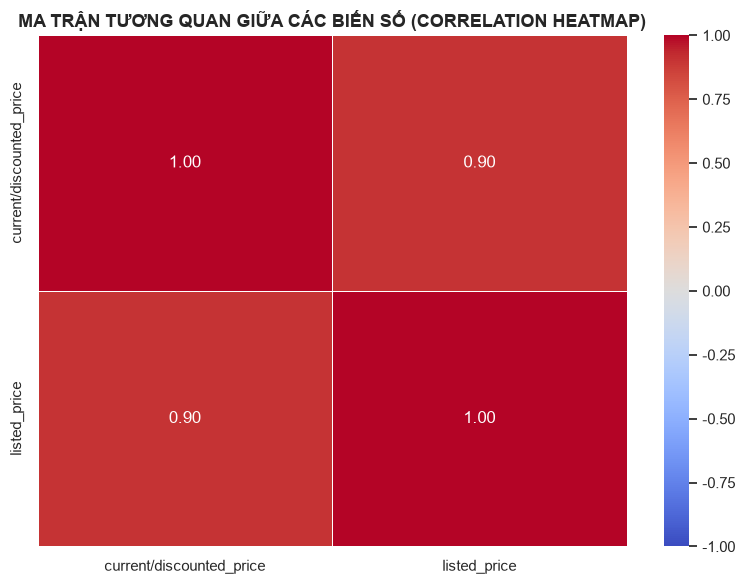

In [10]:
# Lọc lấy các cột định lượng để tính Ma trận Tương quan
numeric_cols = df_eda.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(8, 6))
correlation_matrix = df_eda[numeric_cols].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    vmax=1,
    vmin=-1,
)
plt.title(
    'MA TRẬN TƯƠNG QUAN GIỮA CÁC BIẾN SỐ (CORRELATION HEATMAP)',
    fontsize=13,
    fontweight='bold',
)
plt.tight_layout()
plt.show()

### 📌 TỔNG KẾT KẾT QUẢ KHÁM PHÁ DỮ LIỆU (EDA INSIGHTS):

1. **Chất lượng dữ liệu & Missing Values:**
   * Cột `bought_in_last_month` có tỷ lệ missing values cao, cần được quy đổi dạng chữ `K` thành số thực và gán `NaN` hợp lý.
   * Dữ liệu chứa nhiều cột dạng chuỗi (String) như giá trị tiền tệ dính ký tự đặc biệt, cần được chuyển về dạng số (`float64`/`Int64`).

2. **Phân phối biến mục tiêu (Target Variable):**
   * Doanh số (`bought_in_last_month`) bị lệch phải (Right-skewed) rất mạnh. Đa số các sản phẩm có doanh số dưới 10,000 đơn/tháng, tuy nhiên có những sản phẩm Outliers cực lớn (100,000+ đơn/tháng).

3. **Mối quan hệ giữa các đặc trưng (Features Correlation):**
   * Giá bán thực tế (`actual_price`) có mối tương quan thuận mạnh với Giá niêm yết (`listed_price`).
   * Điểm đánh giá (`rating`) và số lượt đánh giá (`rating_count`) là các yếu tố có tiềm năng ảnh hưởng tích cực đến doanh số bán ra.